# Experiment II: The distribution of k-spacing ratios

In this notebook, we will compute the k-spacing ratios. The k-spacing ratios are, in our convention:

r_k[i] = (z[i+2*k] - z[i+k]) / (z[i+k] - z[i])

where z[i] are the eigenvalues (with or without unfolding).

The literature suggest that they should fit the ABGR surmise with an effective value of beta given by:

beta_k(beta) = k * (k + 1) / 2 * beta + (k - 1)

This formula should hold for infinitely large matrices. At finite N we will see that the range of k for which it holds is quite small, at least in the example of GBE spectra.

In [1]:
# General imports
import numpy as np
import scipy
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

# Import beta_ensembles from source folder
import sys
from pathlib import Path
root_dir = Path.cwd().parent
sys.path.insert(0, str(root_dir / "src"))

import beta_ensembles as be

# Default plotting style
plt.style.use(['seaborn-v0_8','./plot_style.mplstyle'])

def savefig(fname):
    plt.savefig(str(Path.cwd().parent) + '\\figures\\' + fname + '.png')

The effective value of beta for k-spacings is:

In [2]:
def beta_k(beta,k):
    return beta * (k+1) * k / 2 + (k-1)

We will generate large samples of eigenvalues, keeping the number of eigenvalues fixed at 2**20.

We choose in this example to fix beta to the value pi. It has no special significance in this context, just a number close to 3.

In [3]:
beta = np.pi

rng = np.random.default_rng(seed=sum(b'Kilroy was here'))

N_vals = np.array([128,256,512,1024,2048,4096,8192])
n_N = len(N_vals)
                 
n_eigvals = 2**20

all_spectra = []

for i, N in enumerate(tqdm(N_vals,desc='Total progress',position=1)):
    n_spectra = round(n_eigvals/N)
    all_spectra.append(be.gaussian.spectra(beta,N,n_spectra,rng,verbose=True))

Total progress:   0%|          | 0/7 [00:00<?, ?it/s]

Generating GBE spectra: 100%|████████████████████████████████████████████████████████| 128/128 [05:16<00:00,  2.47s/it]


We perform the usual sanity check to see if spectra were generated correctly. Plot the histograms of (the normal, k = 1) spacing ratios, and compare to the ABGR surmise:

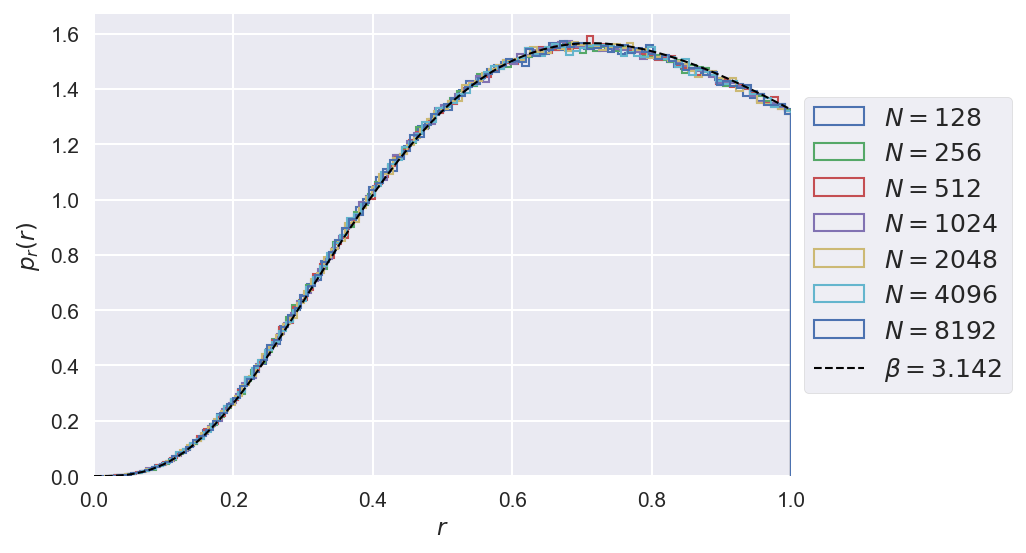

In [4]:
all_ratios = []

for i in range(n_N):
    be.plot.hist_r(be.ratios(all_spectra[i]),histtype='step',lw=1,label=rf'$N = {N_vals[i]:.0f}$');

be.plot.pdf_r(beta,c='k',ls='--',lw=1)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5));

We now fit the beta values for all our samples for all the k-spacing from k = 1 to 13.

This takes some minutes to run.

In [5]:
k_vals = np.arange(1,14)
n_k = len(k_vals)

beta_fit = np.zeros((n_N,n_k))

for i, N in enumerate(tqdm(N_vals)):
    for j, k in enumerate(k_vals):
        r_k = be.k_ratios(all_spectra[i],k)
        beta_fit[i,j] = be.fit_ratios(r_k)

  0%|          | 0/7 [00:00<?, ?it/s]

We plot the beta values we found from the fit and compare to the formula for beta_k(k).

The deviations are large, but it looks like results (very slowly) converge to the expected formula as N is increased. Still, for the largest value of 8192 we are still far away at the largest value of k = 13. With the convergence being logarithmic, we wonder how large would N have to be to agree even for k ~ 10.

This plot is figure 6.5 in our note.

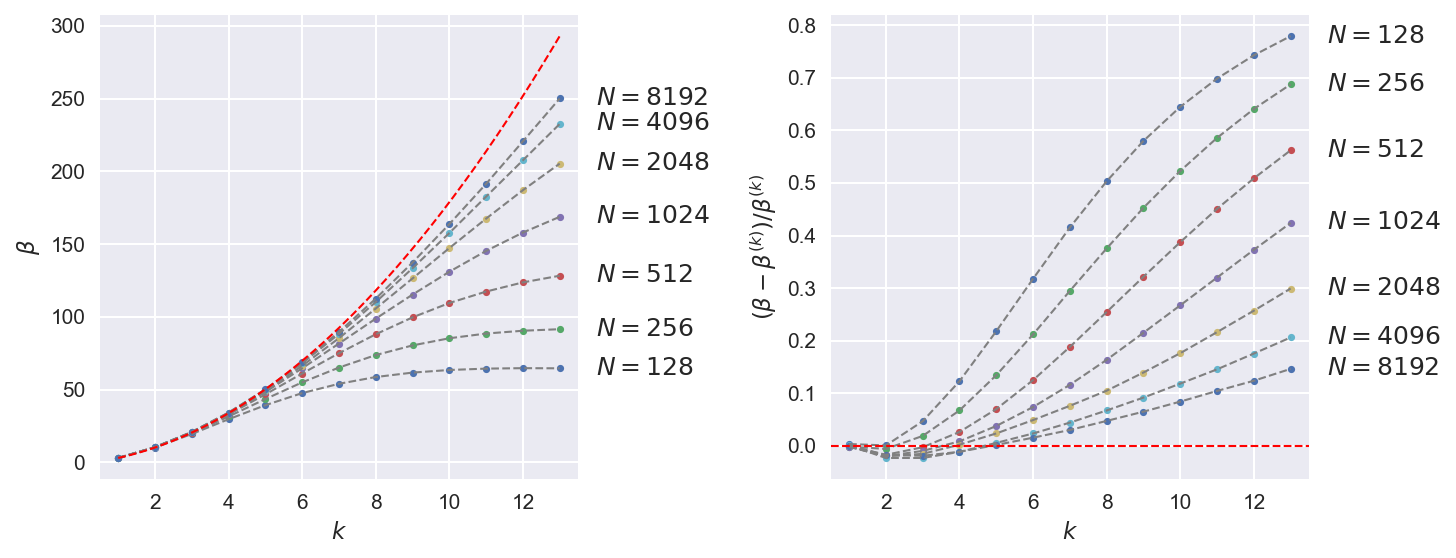

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

beta_1 = beta_fit[:, 0].mean()

kk = np.linspace(k_vals.min(), k_vals.max(), 200)
bb = beta_k(beta_1, kk)

beta_exp = beta_k(beta_1, k_vals)

for i, N in enumerate(N_vals):
    ax1.scatter(k_vals, beta_fit[i], lw=1, s=6)
    ax1.plot(k_vals, beta_fit[i], lw=1, c='gray', ls='--')
    ax1.text(k_vals[-1]+1, beta_fit[i, -1], rf'$N={N}$',
             va='center', ha='left',fontsize=12)

    yy = (beta_exp - beta_fit[i]) / beta_exp
    ax2.scatter(k_vals, yy, lw=1, s=6)
    ax2.plot(k_vals, yy, lw=1, c='gray', ls='--')
    ax2.text(k_vals[-1]+1, yy[-1], rf'$N={N}$',
             va='center', ha='left',fontsize=12)


ax1.plot(kk, bb, ls='--', c='r', lw=1)
ax2.axhline(0, c='r', ls='--', lw=1)

ax1.set_xlabel(r'$k$')
ax1.set_ylabel(r'$\beta$')

ax2.set_xlabel(r'$k$')
ax2.set_ylabel(r'$(\beta-\beta^{(k)})/\beta^{(k)}$')

ax1.set_xlim(k_vals.min()-0.5,k_vals.max()+0.5)
ax2.set_xlim(k_vals.min()-0.5,k_vals.max()+0.5)

plt.tight_layout()

# Save figure
# savefig('2a_temp')

By plotting histograms below, we see that the problem is worse than just having the "wrong" value of beta. The ABGR surmise simply does not agree with the samples as k is increased. There's no effective value of beta at large k, it is a differrent distribution altogether.

This is figure 6.6.

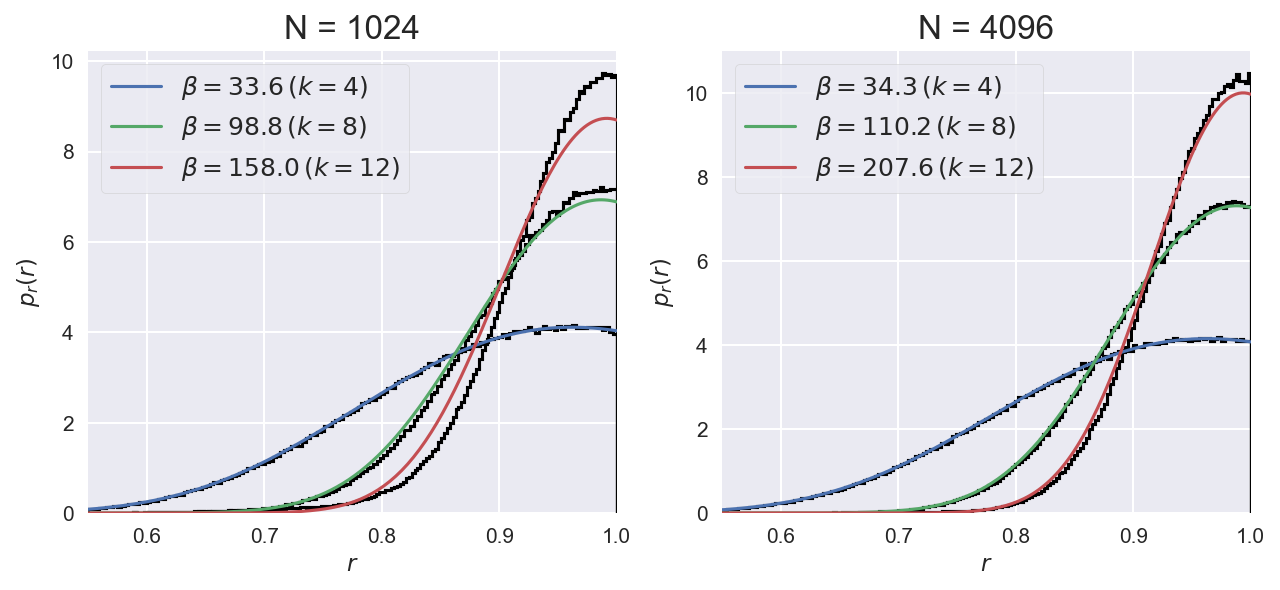

In [7]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10,4))

for j, i in enumerate([3,-2]):
    plt.subplot(1,2,j+1)

    kk = [4,8,12]

    for k in kk:
        r = be.k_ratios(all_spectra[i],k=k)
        be.plot.hist_r(r,histtype='step',lw=1.5,color='k',bins=200)

    for k in kk:
        bb = beta_fit[i,k-1]
        be.plot.pdf_r(bb,label=rf'$\beta = {bb:.1f}\, (k = {k})$',lw=1.5)
        # be.plot.pdf_r(beta_k(beta_fit[i,0],k),label=rf'$\beta = \beta^{{({k})}}$',lw=1.5,ls='--')

    plt.title(f'N = {N_vals[i]}')
    plt.xlim(0.55,1)
    plt.legend()

# Save figure
# savefig('2b_temp')